In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='tenx_5K_pbmc_rnaseq',
    zarr=True,
    destination='scarf_datasets'
)

Downloading bucket files: 38209567 / 38209567 complete

Downloading bytes: 38209567 / 38209567 complete

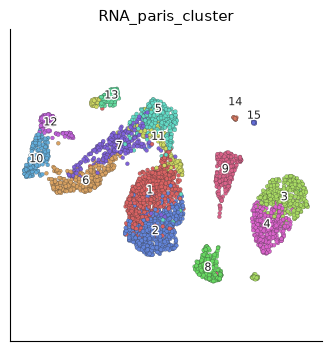

In [3]:
ds = scarf.DataStore(f'{dataset}/data.zarr')

ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
)

In [4]:
ds.run_topacedo_sampler(
    cluster_key='RNA_paris_cluster',
    max_sampling_rate=0.1
)
if 'RNA_sketched' not in ds.cells.columns:
    raise RuntimeError(
        "TopACeDo did not create RNA_sketched. Verify that topacedo is installed."
    )

print('Active cells:', int(ds.cells.fetch_all('I').sum()))
print('Selected cells:', int(ds.cells.fetch_all('RNA_sketched').sum()))

INFO: 368 cells (9.34%) sub-sampled. Subsample to Seed (158 cells) ratio: 2.329


Constructing graph from dendrogram: 3939 / 3939 complete

Active cells: 3940


Selected cells: 368


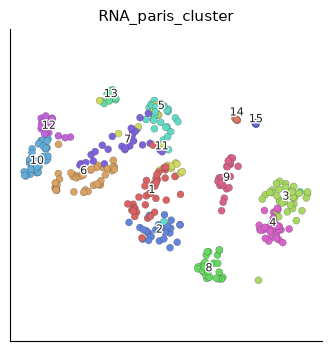

In [5]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketched',
)

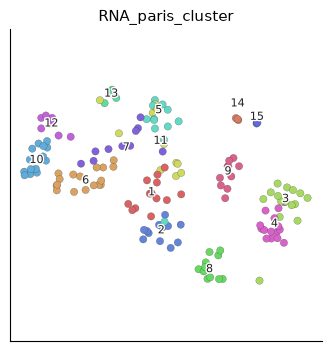

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_paris_cluster',
    subset_by='RNA_sketch_seeds',
)

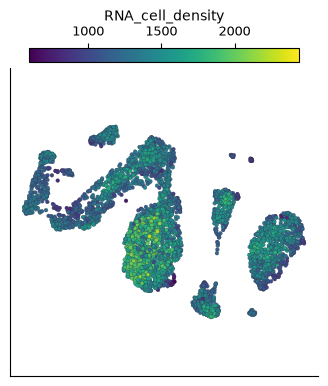

In [7]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_cell_density',
)

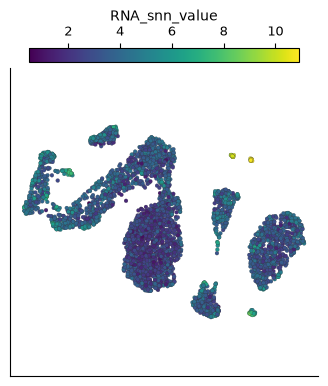

In [8]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='RNA_snn_value',
)

In [9]:
subset_path = f'{dataset}/subset.zarr'
writer = scarf.SubsetZarr(
    zarr_loc=subset_path,
    assays=[ds.RNA],
    cell_key='RNA_sketched',
    reset_cell_filter=False,
    overwrite_existing_file=True,
)
writer.dump()

Subsetting assay: RNA: 1 / 1 complete

In [10]:
ds2 = scarf.DataStore(subset_path)
{
    "source cells": ds.cells.N,
    "subset cells": ds2.cells.N,
    "source RNA features": ds.RNA.feats.N,
    "subset RNA features": ds2.RNA.feats.N,
}

Computing RNA initialization statistics: 1 / 1 complete

{'source cells': 5025,
 'subset cells': 368,
 'source RNA features': 33538,
 'subset RNA features': 33538}

In [11]:
adata = ds2.to_anndata()
adata.shape

Converting RNA raw data to CSR: 1 / 1 complete

(368, 33538)